In [38]:
!pip install --upgrade "google-cloud-bigquery[bqstorage,pandas]"

from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
import pandas as pd

PROJECT_ID = "data-analytics-mate"

client = bigquery.Client(project=PROJECT_ID)
print("Connected to project:", PROJECT_ID)

Connected to project: data-analytics-mate


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, pearsonr, shapiro, mannwhitneyu, kruskal
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency

In [40]:
query = """
SELECT
  s.date AS session_date,
  s.ga_session_id,
  o.item_id,
  sp.continent,
  sp.country,
  sp.device,
  sp.browser,
  sp.mobile_model_name AS model_name,
  sp.operating_system,
  sp.language,
  sp.name AS traffic_source,
  sp.channel AS traffic_channel,
  a.id AS user_id,
CASE
  WHEN a.id IS NULL THEN NULL
  ELSE CAST(a.is_verified AS INT64)
END AS email_confirmed,
CASE
  WHEN a.id IS NULL THEN NULL
  WHEN a.is_unsubscribed = 1 THEN 0
  ELSE 1
END AS is_subscribed,
  p.category,
  p.name AS product_name,
  p.price,
  p.short_description
FROM `data-analytics-mate.DA.session` s
LEFT JOIN `data-analytics-mate.DA.order` o
  ON s.ga_session_id = o.ga_session_id
LEFT JOIN `data-analytics-mate.DA.session_params` sp
  ON s.ga_session_id = sp.ga_session_id
LEFT JOIN `data-analytics-mate.DA.product` p
  ON o.item_id = p.item_id
LEFT JOIN `data-analytics-mate.DA.account_session` acs
  ON s.ga_session_id = acs.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account` a
  ON acs.account_id = a.id
"""

In [41]:
df = client.query(query).to_dataframe()
print(df.shape)
print(df.head())
print(df.info())

(349545, 19)
  session_date  ga_session_id   item_id continent         country   device  \
0   2020-11-01     5760483956  99902661  Americas   United States  desktop   
1   2020-11-01     7115337200  99902661    Europe  United Kingdom  desktop   
2   2020-11-01     3978035233  20382932    Europe          Norway   mobile   
3   2020-11-01     9648986282  99902661    Africa         Nigeria   mobile   
4   2020-11-01     4393441533  99902661      Asia           China  desktop   

  browser model_name operating_system language traffic_source traffic_channel  \
0  Chrome     Safari        Macintosh       zh        <Other>     Paid Search   
1  Chrome     Chrome              Web    en-us      (organic)  Organic Search   
2  Chrome    <Other>              Web       zh       (direct)          Direct   
3  Chrome    <Other>          Android    es-es       (direct)          Direct   
4  Chrome     Chrome          Windows    en-us       (direct)          Direct   

   user_id  email_confirmed  is

**Висновок**

На цьому етапі було сформовано фінальний аналітичний датасет із Google BigQuery, який містить інформацію про сесії, замовлення, користувачів, товари, девайси та джерела трафіку. Саме цей датасет буде використано для подальшого розвідувального, бізнесового та статистичного аналізу.

In [42]:
print("Rows, columns:", df.shape)

numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
datetime_cols = df.select_dtypes(include=['datetime64[ns]']).columns.tolist()

print("Numeric columns:", len(numeric_cols), numeric_cols)
print("Categorical columns:", len(categorical_cols), categorical_cols)
print("Datetime columns:", len(datetime_cols), datetime_cols)

print("Unique sessions:", df['ga_session_id'].nunique())
print("Period:", df['session_date'].min(), "to", df['session_date'].max())

missing_count = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent
}).sort_values(by='missing_count', ascending=False)

print(missing_summary[missing_summary['missing_count'] > 0])

Rows, columns: (349545, 19)
Numeric columns: 6 ['ga_session_id', 'item_id', 'user_id', 'email_confirmed', 'is_subscribed', 'price']
Categorical columns: 12 ['continent', 'country', 'device', 'browser', 'model_name', 'operating_system', 'language', 'traffic_source', 'traffic_channel', 'category', 'product_name', 'short_description']
Datetime columns: 0 []
Unique sessions: 349545
Period: 2020-11-01 to 2021-01-31
                   missing_count  missing_percent
user_id                   321600            92.01
is_subscribed             321600            92.01
email_confirmed           321600            92.01
product_name              316007            90.41
short_description         316007            90.41
item_id                   316007            90.41
category                  316007            90.41
price                     316007            90.41
language                  114266            32.69


Отриманий датасет містить 349545 рядків та 19 колонок. Серед них виділено 6 колонок числового типу, 12 категоріальних та 1 колонку типу datetime. Датасет охоплює період з 01.11.2020 до 31.01.2021 та містить 349545 унікальних сесій. Найбільше пропущених значень спостерігається в колонках user_id, is_subscribed, email_confirmed, item_id, price, category, product_name та short_description. Це пояснюється тим, що датасет побудований на основі всіх сесій сайту, включно із сесіями без покупки та без авторизації користувача.

In [43]:
orders_df = df[df['item_id'].notna()].copy()
orders_df['revenue'] = orders_df['price'].fillna(0)

Для аналізу продажів окремо сформовано вибірку orders_df, яка містить лише сесії з покупками. Це дозволяє коректно аналізувати дохід, категорії товарів, країни та поведінку користувачів саме в контексті продажів.

continent
Americas    17665280.0
Asia         7601298.3
Europe       5934624.2
Name: revenue, dtype: float64


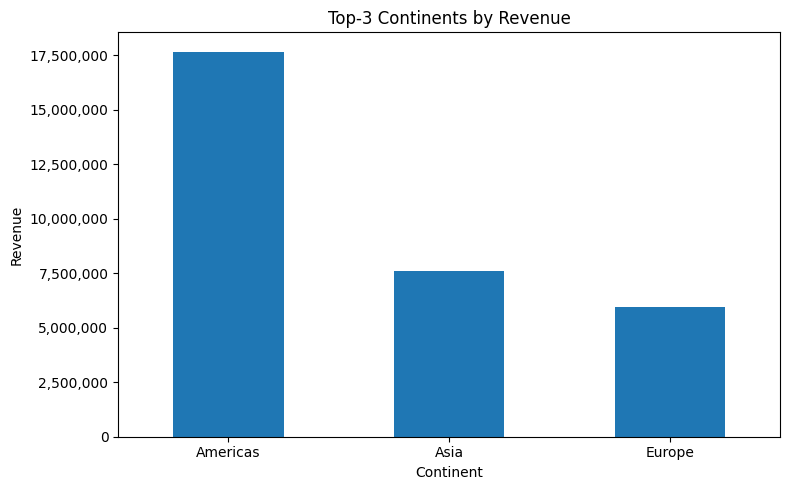

In [44]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

continent_sales = (
    orders_df.groupby('continent')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(3)
)
print(continent_sales)

plt.figure(figsize=(8,5))
ax = continent_sales.plot(kind='bar')

plt.title('Top-3 Continents by Revenue')
plt.xlabel('Continent')
plt.ylabel('Revenue')
plt.xticks(rotation=0)

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

**Аналіз доходу за континентами**

---

Найбільший дохід компанія отримує в регіоні Americas, який суттєво випереджає Азію та Європу. Друге місце займає Asia, третє — Europe. Це свідчить про те, що ключовий ринок компанії зосереджений саме в Americas, де формується основна частка загального доходу.
Така домінантна позиція може пояснюватися більшою купівельною спроможністю клієнтів або сильнішою присутністю бренду в цьому регіоні.


country
United States     13943553.9
India              2809762.0
Canada             2437921.0
United Kingdom      938317.9
France              710692.8
Name: revenue, dtype: float64


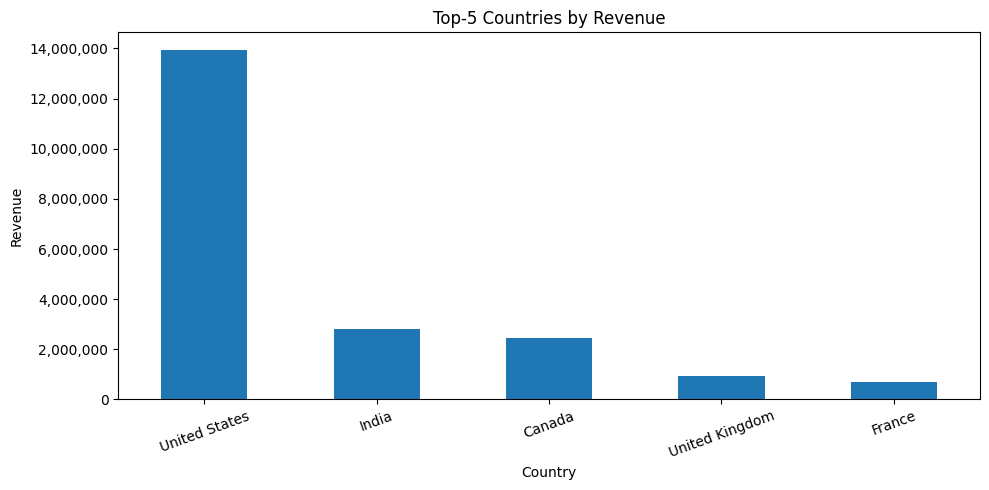

In [45]:
country_sales = (
    orders_df.groupby('country')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print(country_sales)

from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10,5))
ax = country_sales.plot(kind='bar')
plt.title('Top-5 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=20)

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

**Аналіз доходу за країнами**

---

Сполучені Штати Америки є беззаперечним лідером за обсягом доходу та значно випереджають інші країни.
Доходи з Індії та Канади також демонструють високі показники, що може свідчити про потенціал для подальшого зростання на цих ринках.
Європейські країни, зокрема Велика Британія та Франція, формують помірний рівень доходу порівняно з лідерами.
Таким чином, дохід компанії суттєво концентрується на ринку США.

country
United States     14673
India              3029
Canada             2560
United Kingdom     1029
France              678
Name: ga_session_id, dtype: int64


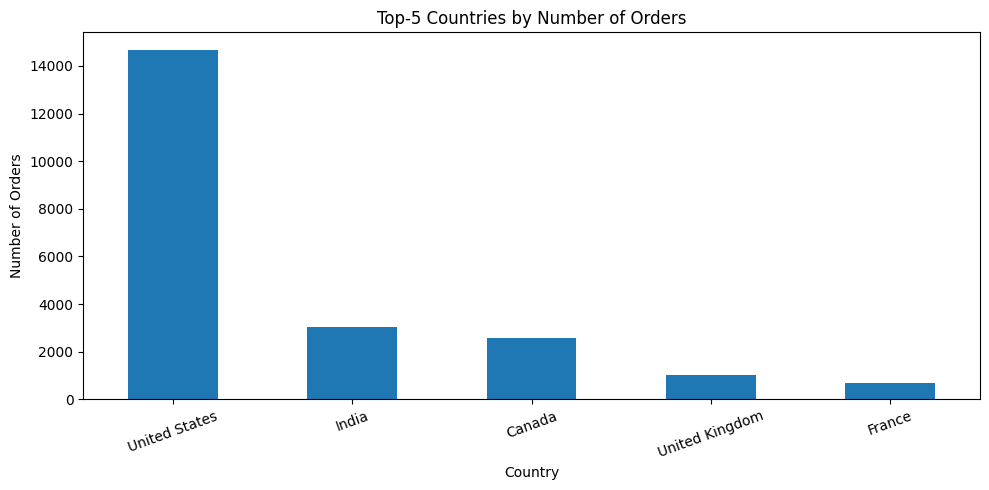

In [46]:
orders_by_country = (
    orders_df.groupby('country')['ga_session_id']
    .nunique()
    .sort_values(ascending=False)
    .head(5)
)
print(orders_by_country)

plt.figure(figsize=(10,5))
orders_by_country.plot(kind='bar')
plt.title('Top-5 Countries by Number of Orders')
plt.xlabel('Country')
plt.ylabel('Number of Orders')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Аналіз кількості замовлень за країнами.**

---

Найбільша кількість замовлень припадає на United States, які суттєво випереджають інші країни. Друге та третє місця займають India і Canada. Це свідчить про високу концентрацію попиту на ринку США порівняно з іншими країнами.

continent
Americas    18553
Asia         7950
Europe       6261
Name: ga_session_id, dtype: int64


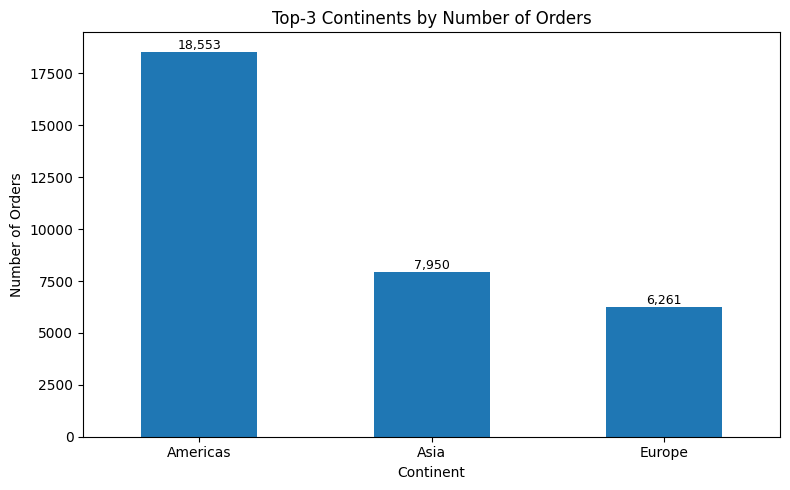

In [80]:
orders_by_continent = (
    orders_df.groupby('continent')['ga_session_id']
    .nunique()
    .sort_values(ascending=False)
    .head(3)
)

print(orders_by_continent)

plt.figure(figsize=(8,5))
ax = orders_by_continent.plot(kind='bar')
plt.title('Top-3 Continents by Number of Orders')
plt.xlabel('Continent')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)

for i, v in enumerate(orders_by_continent.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Аналіз кількості замовлень за континентами.**  
Найбільша кількість замовлень припадає на **Americas**, які суттєво випереджають інші континенти. Друге місце займає **Asia**, а третє — **Europe**. Це свідчить про те, що основний попит на товари компанії зосереджений саме в регіоні Americas, який є ключовим не лише за доходом, а і за кількістю оформлених замовлень.

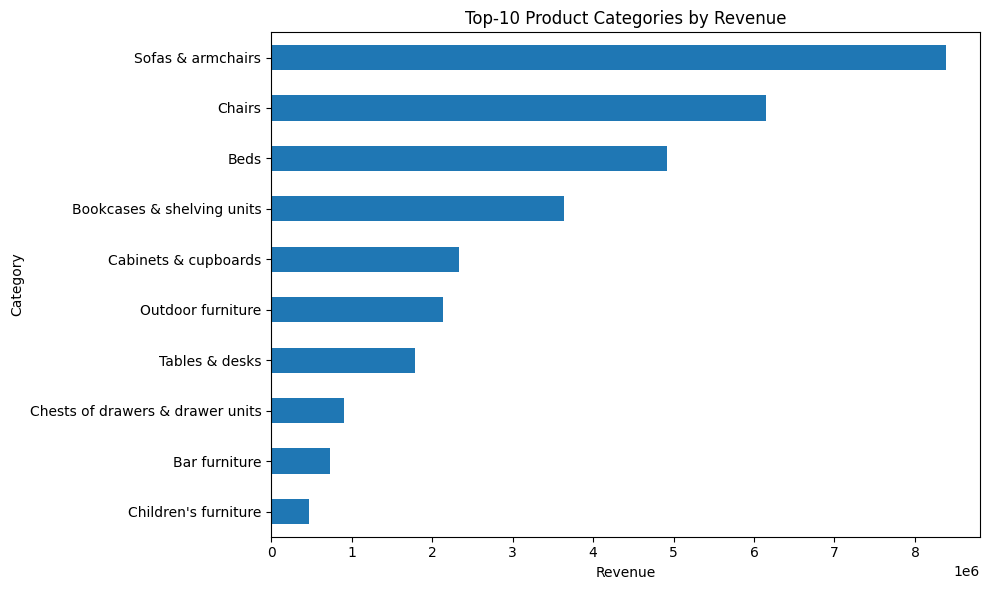

In [47]:
category_sales = (
    orders_df.groupby('category')['revenue']
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)

plt.figure(figsize=(10,6))
category_sales.plot(kind='barh')
plt.title('Top-10 Product Categories by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

**Аналіз доходу за категоріями товарів**

---


Найбільший дохід генерує категорія "Sofas & armchairs", що свідчить про високий попит на великі меблі для дому.
Друге та третє місце займають категорії "Chairs" та "Beds".
Отримані результати вказують на те, що основний обсяг доходу формується за рахунок базових меблів для облаштування житла, а не дрібних товарів або аксесуарів.
Це може відображати позиціонування компанії як постачальника основних меблевих рішень для дому.

Top country by revenue: United States
Revenue: 13943553.9
category
Sofas & armchairs                   3707144.5
Chairs                              2619773.8
Beds                                2213058.0
Bookcases & shelving units          1567606.9
Cabinets & cupboards                 994545.5
Outdoor furniture                    929245.2
Tables & desks                       777865.0
Chests of drawers & drawer units     382388.0
Bar furniture                        330805.0
Children's furniture                 207575.0
Name: revenue, dtype: float64


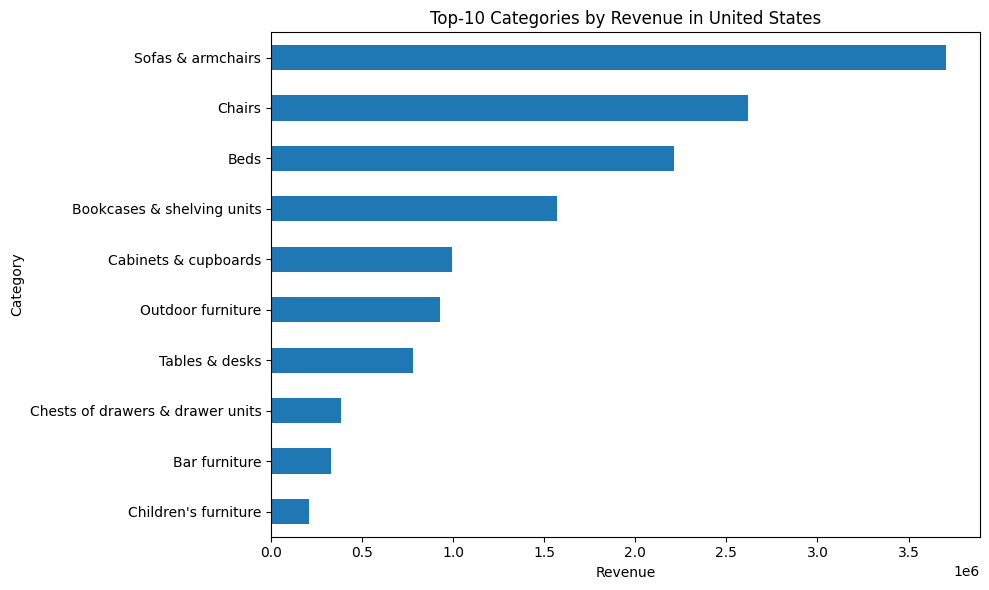

In [48]:
top_country = orders_df.groupby('country')['revenue'].sum().idxmax()
top_country_revenue = orders_df.groupby('country')['revenue'].sum().max()

print("Top country by revenue:", top_country)
print("Revenue:", round(top_country_revenue, 2))

top_categories_top_country = (
    orders_df[orders_df['country'] == top_country]
    .groupby('category')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_categories_top_country)

plt.figure(figsize=(10,6))
top_categories_top_country.sort_values().plot(kind='barh')
plt.title(f'Top-10 Categories by Revenue in {top_country}')
plt.xlabel('Revenue')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

**Аналіз топ-10 категорій у країні з найбільшими продажами.**

---

Країною з найбільшим обсягом продажів є United States. У цій країні, як і в загальному зрізі, серед лідерів залишаються базові меблеві категорії, зокрема Sofas & armchairs, Chairs та Beds. Це свідчить про те, що структура попиту на основному ринку компанії загалом відповідає загальній структурі продажів.

device
desktop    59.00
mobile     38.73
tablet      2.26
Name: revenue, dtype: float64


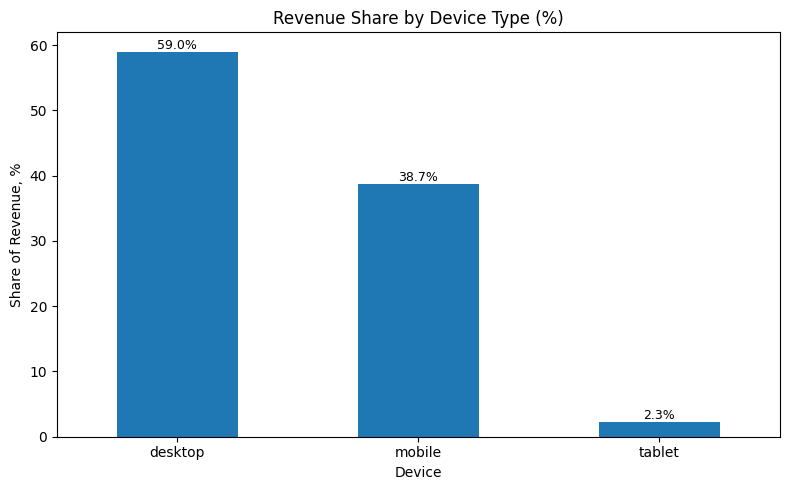

In [49]:
device_share = (
    orders_df.groupby('device')['revenue']
    .sum()
    .div(orders_df['revenue'].sum())
    .mul(100)
    .sort_values(ascending=False)
)

print(device_share.round(2))

plt.figure(figsize=(8,5))
ax = device_share.plot(kind='bar')
plt.title('Revenue Share by Device Type (%)')
plt.xlabel('Device')
plt.ylabel('Share of Revenue, %')
plt.xticks(rotation=0)

for i, v in enumerate(device_share.values):
    ax.text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Аналіз продажів за типами девайсів.**

---

Найбільша частка доходу припадає на desktop, який генерує основний обсяг продажів. Mobile також формує значну частку доходу, але поступається desktop. Tablet має мінімальний внесок у загальний дохід, тому цей тип девайсу є найменш важливим з точки зору продажів.

model_name
Chrome        8899523.9
<Other>       6535330.8
Safari        6491062.1
iPhone        6420776.3
ChromeBook    1830458.7
Edge           697222.3
iPad           448854.2
Firefox        421066.9
Pixel 4 XL     118287.7
Pixel 3        109148.2
Name: revenue, dtype: float64


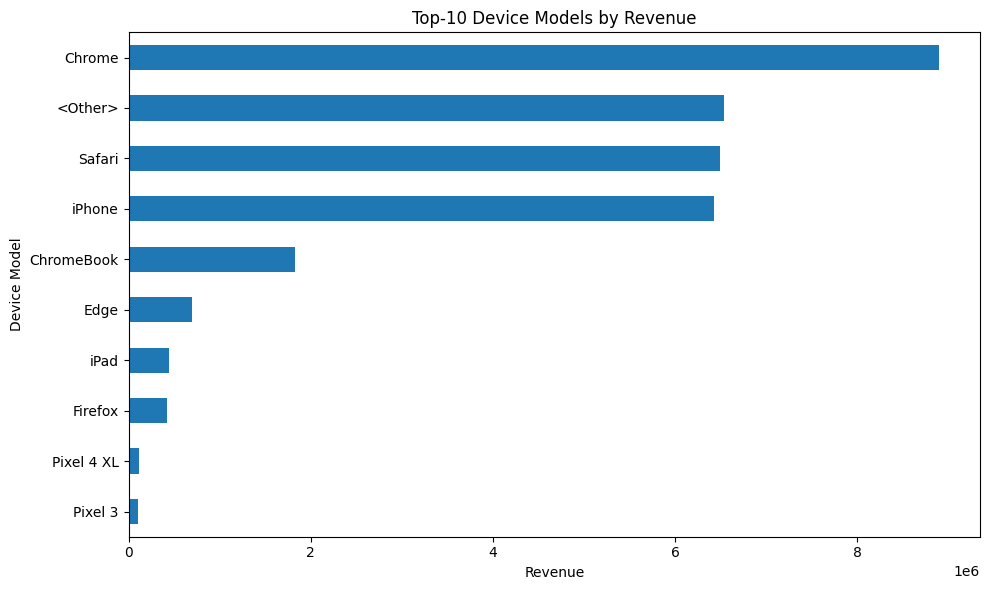

In [50]:
model_sales = (
    orders_df.groupby('model_name')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(model_sales)

plt.figure(figsize=(10,6))
model_sales.sort_values().plot(kind='barh')
plt.title('Top-10 Device Models by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Device Model')
plt.tight_layout()
plt.show()

**Аналіз продажів за моделями девайсів.**

---

Найбільший дохід генерують кілька конкретних моделей пристроїв, що свідчить про нерівномірний розподіл продажів між моделями. Це може вказувати на різну якість трафіку або поведінку користувачів залежно від типу пристрою. Для компанії це корисно з точки зору оптимізації мобільного досвіду користувача.

model_name
Chrome        27.84
<Other>       20.44
Safari        20.30
iPhone        20.08
ChromeBook     5.73
Edge           2.18
iPad           1.40
Firefox        1.32
Pixel 4 XL     0.37
Pixel 3        0.34
Name: revenue, dtype: float64


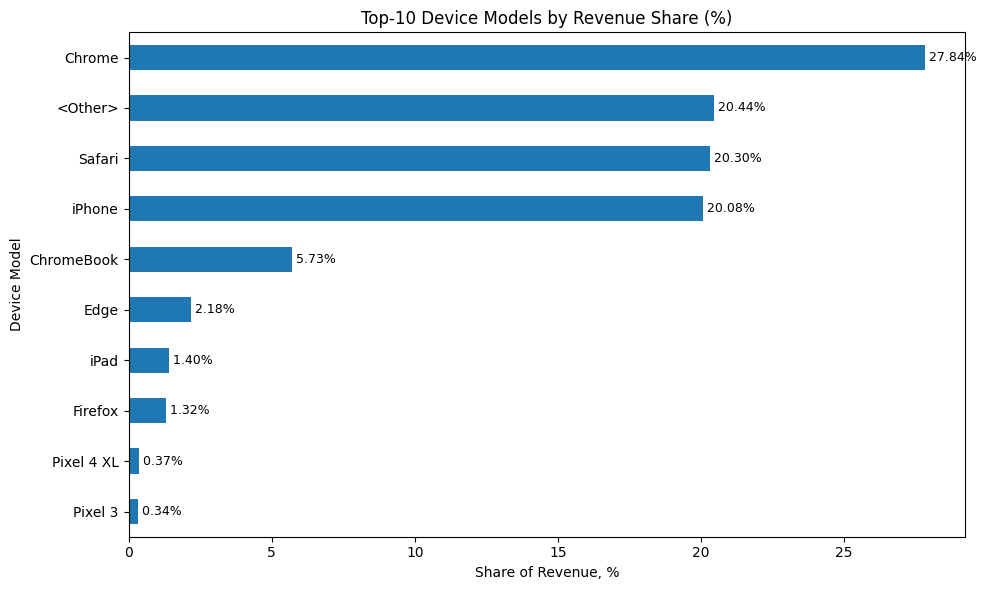

In [81]:
model_share = (
    orders_df.dropna(subset=['model_name'])
    .groupby('model_name')['revenue']
    .sum()
    .div(orders_df['revenue'].sum())
    .mul(100)
    .sort_values(ascending=False)
    .head(10)
)

print(model_share.round(2))

plt.figure(figsize=(10,6))
ax = model_share.sort_values().plot(kind='barh')
plt.title('Top-10 Device Models by Revenue Share (%)')
plt.xlabel('Share of Revenue, %')
plt.ylabel('Device Model')

for i, v in enumerate(model_share.sort_values().values):
    ax.text(v, i, f' {v:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Аналіз продажів за моделями девайсів (у % від загального доходу).**  
Найбільшу частку доходу формують лише кілька моделей пристроїв, тоді як внесок більшості інших моделей є суттєво нижчим. Це свідчить про нерівномірний розподіл продажів між моделями девайсів і може вказувати на відмінності в поведінці користувачів, якості трафіку або зручності взаємодії з сайтом на певних пристроях. Отримані результати можуть бути корисними для оптимізації користувацького досвіду на найбільш важливих моделях.

traffic_channel
Organic Search    35.76
Paid Search       26.62
Direct            23.44
Social Search      7.92
Undefined          6.26
Name: revenue, dtype: float64


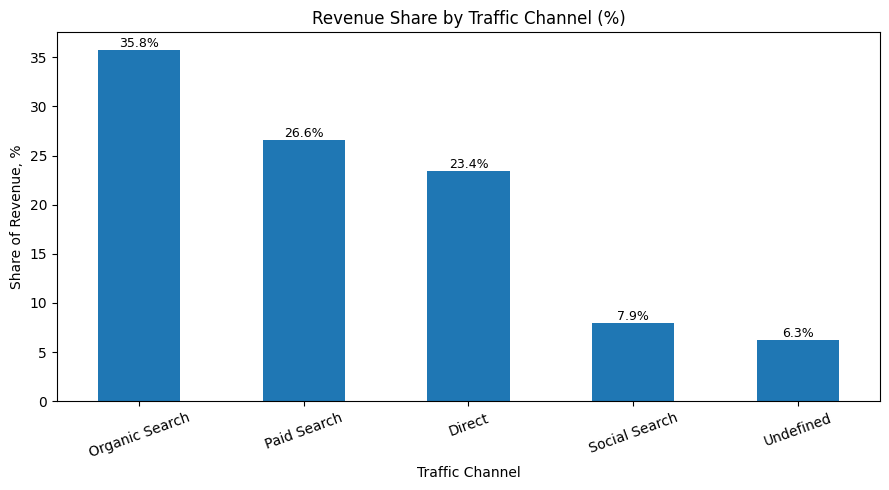

In [51]:
traffic_share = (
    orders_df.groupby('traffic_channel')['revenue']
    .sum()
    .div(orders_df['revenue'].sum())
    .mul(100)
    .sort_values(ascending=False)
)

print(traffic_share.round(2))

plt.figure(figsize=(9,5))
ax = traffic_share.plot(kind='bar')
plt.title('Revenue Share by Traffic Channel (%)')
plt.xlabel('Traffic Channel')
plt.ylabel('Share of Revenue, %')
plt.xticks(rotation=20)

for i, v in enumerate(traffic_share.values):
    ax.text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Аналіз продажів за каналами трафіку.**

---

Найбільшу частку доходу формує Organic Search, що свідчить про високу ефективність органічного пошуку. Друге місце займає Paid Search, а третє — Direct. Канали Social Search та Undefined мають значно менший внесок у загальний дохід.

In [52]:
users = (
    df[['user_id', 'email_confirmed', 'is_subscribed']]
    .dropna(subset=['user_id'])
    .drop_duplicates(subset=['user_id'])
)

verified_pct = users['email_confirmed'].mean() * 100
subscribed_pct = users['is_subscribed'].mean() * 100
unsubscribed_pct = 100 - subscribed_pct

print("Verified email %:", round(verified_pct, 2))
print("Subscribed %:", round(subscribed_pct, 2))
print("Unsubscribed %:", round(unsubscribed_pct, 2))

Verified email %: 71.7
Subscribed %: 83.06
Unsubscribed %: 16.94


**Аналіз підтвердження email та статусу підписки.**

---

Серед зареєстрованих користувачів 71.7% підтвердили свою електронну адресу.

In [53]:
subscribed_pct = users['is_subscribed'].mean() * 100
unsubscribed_pct = 100 - subscribed_pct

print("Subscribed %:", round(subscribed_pct, 2))
print("Unsubscribed %:", round(unsubscribed_pct, 2))

Subscribed %: 83.06
Unsubscribed %: 16.94


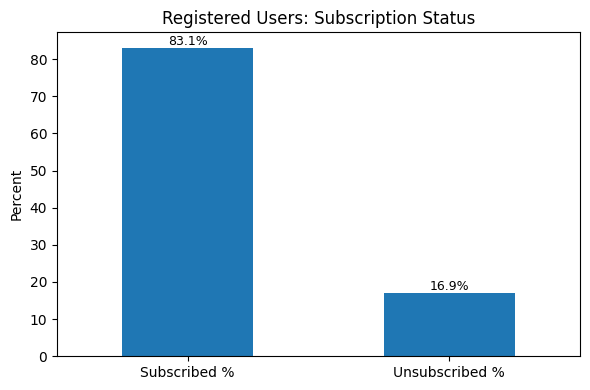

In [54]:
subscription_stats = pd.Series({
    'Subscribed %': subscribed_pct,
    'Unsubscribed %': unsubscribed_pct
})

plt.figure(figsize=(6,4))
ax = subscription_stats.plot(kind='bar')
plt.title('Registered Users: Subscription Status')
plt.ylabel('Percent')
plt.xticks(rotation=0)

for i, v in enumerate(subscription_stats.values):
    ax.text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Більшість користувачів, а саме 83.06%, залишаються підписаними на розсилку, тоді як 16.94% відписалися. Це свідчить про достатньо високий рівень залучення зареєстрованих користувачів до комунікації з брендом.

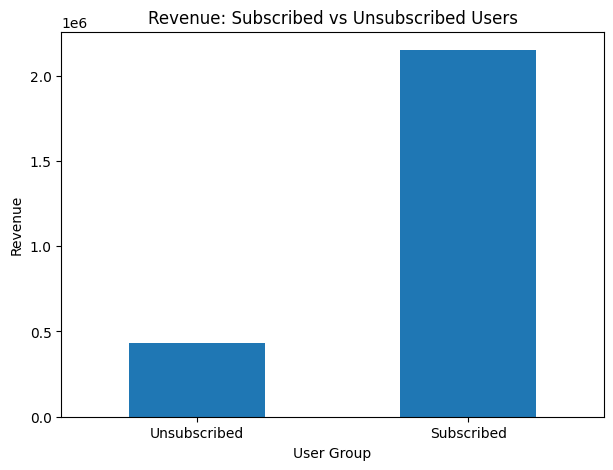

In [55]:
user_sales = (
    orders_df.dropna(subset=['user_id', 'is_subscribed'])
    .groupby('is_subscribed')['revenue']
    .sum()
)

user_sales.index = ['Unsubscribed', 'Subscribed']

plt.figure(figsize=(7,5))
user_sales.plot(kind='bar')
plt.title('Revenue: Subscribed vs Unsubscribed Users')
plt.xlabel('User Group')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()

Основна частина доходу формується користувачами, які залишаються підписаними на розсилку.

country
United States     12384
India              2687
Canada             2067
United Kingdom      859
France              553
Spain               536
Taiwan              500
China               490
Germany             490
Italy               386
Name: user_id, dtype: int64


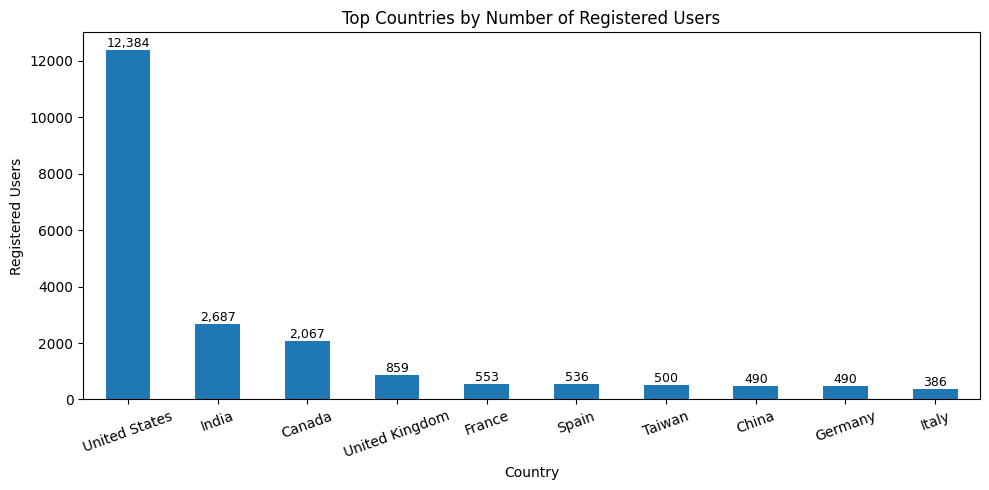

In [56]:
registered_users_by_country = (
    df.dropna(subset=['user_id'])
    .groupby('country')['user_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

print(registered_users_by_country)

plt.figure(figsize=(10,5))
ax = registered_users_by_country.plot(kind='bar')
plt.title('Top Countries by Number of Registered Users')
plt.xlabel('Country')
plt.ylabel('Registered Users')
plt.xticks(rotation=20)

for i, v in enumerate(registered_users_by_country.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Аналіз країн за кількістю зареєстрованих користувачів.**

---

Найбільша кількість зареєстрованих користувачів спостерігається у United States, які суттєво випереджають інші країни. Також відносно високі показники мають India та Canada. Це свідчить про те, що база зареєстрованих користувачів компанії найбільш концентрована на ринку США.

browser
Chrome             21826850.0
Safari              7526544.0
<Other>              923354.8
Edge                 716444.3
Firefox              567523.6
Android Webview      411014.4
Name: revenue, dtype: float64


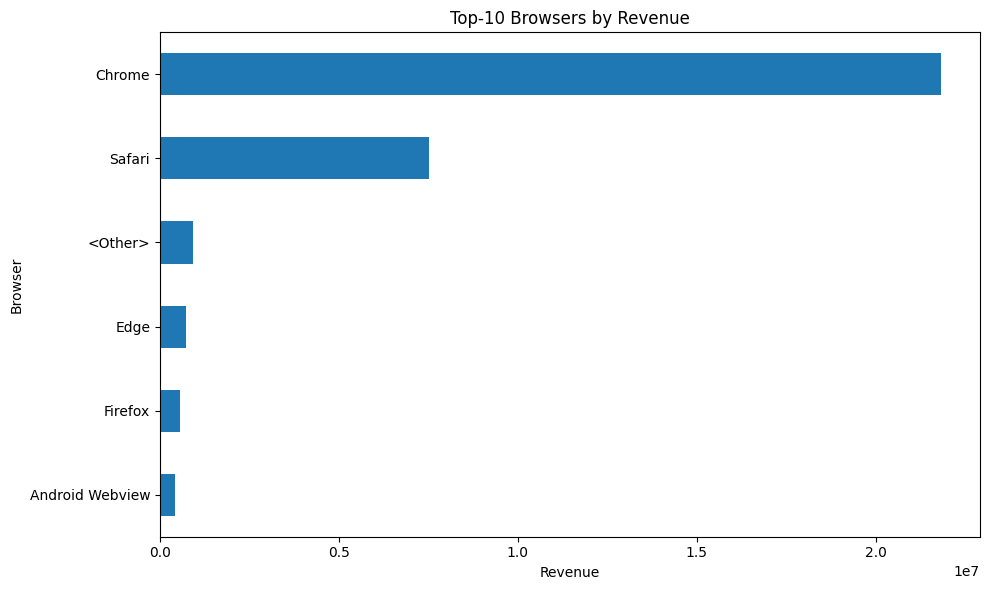

In [57]:
browser_sales = (
    orders_df.groupby('browser')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(browser_sales)

plt.figure(figsize=(10,6))
browser_sales.sort_values().plot(kind='barh')
plt.title('Top-10 Browsers by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Browser')
plt.tight_layout()
plt.show()

**Аналіз продажів за браузерами.**

---

Найбільший дохід компанії генерує браузер Chrome, який суттєво випереджає інші браузери. Це свідчить про те, що основна частина користувачів здійснює покупки саме через Chrome, а отже цей браузер є ключовим з точки зору користувацького досвіду та оптимізації сайту. Інші браузери формують значно менший внесок у дохід, що може відображати як меншу частку користувачів, так і відмінності в їхній поведінці. Отримані результати можуть бути корисними для технічної пріоритезації, зокрема для тестування та покращення роботи сайту насамперед у середовищі Chrome.

weekday
Monday       4636290.4
Tuesday      5457515.9
Wednesday    5466542.9
Thursday     4936935.6
Friday       4523067.2
Saturday     3477990.9
Sunday       3473388.2
Name: revenue, dtype: float64


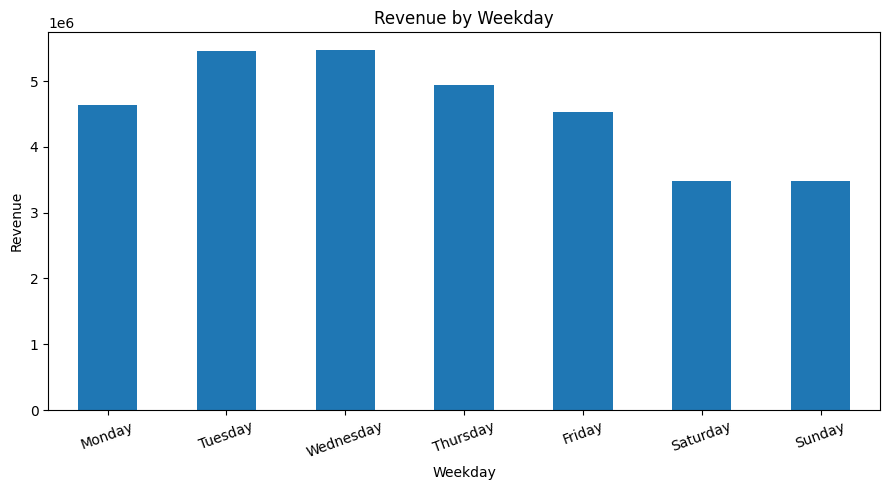

In [58]:
orders_df['session_date'] = pd.to_datetime(orders_df['session_date'])
orders_df['weekday'] = orders_df['session_date'].dt.day_name()

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_sales = (
    orders_df.groupby('weekday')['revenue']
    .sum()
    .reindex(weekday_order)
)

print(weekday_sales)

plt.figure(figsize=(9,5))
weekday_sales.plot(kind='bar')
plt.title('Revenue by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Revenue')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Аналіз продажів за днями тижня.**

---

Розподіл доходу за днями тижня показує, що обсяг продажів відрізняється залежно від дня. Дні з вищим доходом можуть свідчити про більш активну поведінку користувачів у цей період, тоді як дні з нижчим доходом можуть вказувати на спад попиту. Такий аналіз дозволяє краще зрозуміти тижневу циклічність продажів і може бути корисним для планування маркетингових активностей, рекламних кампаній та розподілу ресурсів.

session_date
2020-11-01    244292.5
2020-11-02    355506.8
2020-11-03    498979.6
2020-11-04    339187.1
2020-11-05    391276.6
Name: revenue, dtype: float64


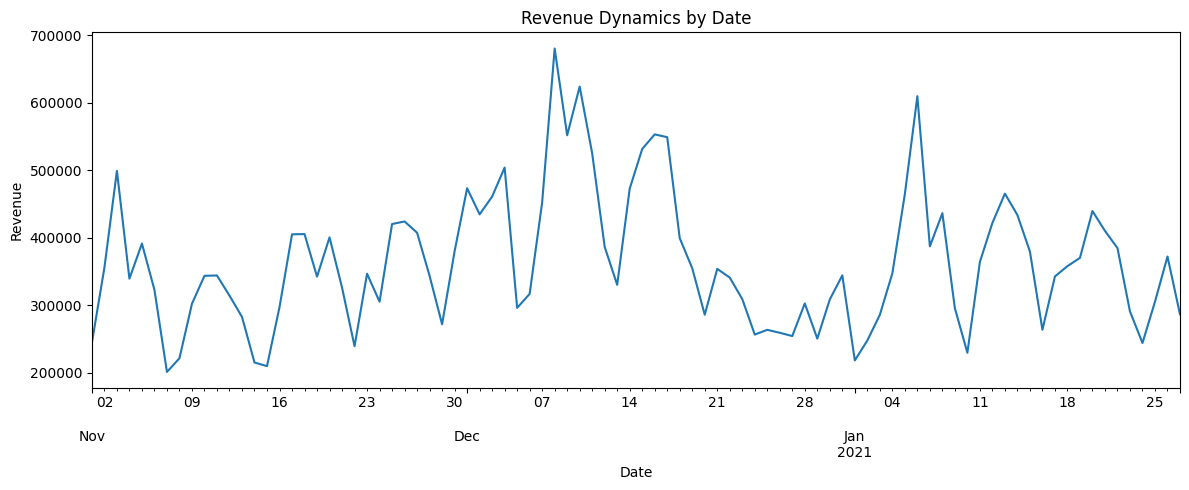

In [59]:
daily_sales = orders_df.groupby('session_date')['revenue'].sum()

print(daily_sales.head())

plt.figure(figsize=(12,5))
daily_sales.plot()
plt.title('Revenue Dynamics by Date')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

**Аналіз динаміки загальних продажів за датами.**

---

Протягом досліджуваного періоду продажі коливаються нерівномірно, із помітними піками та спадами в окремі дні. Найвищі значення спостерігаються у грудні та на початку січня, що може свідчити про сезонне зростання попиту в період свят. Загалом динаміка продажів є волатильною, без стабільного рівня щоденного доходу.

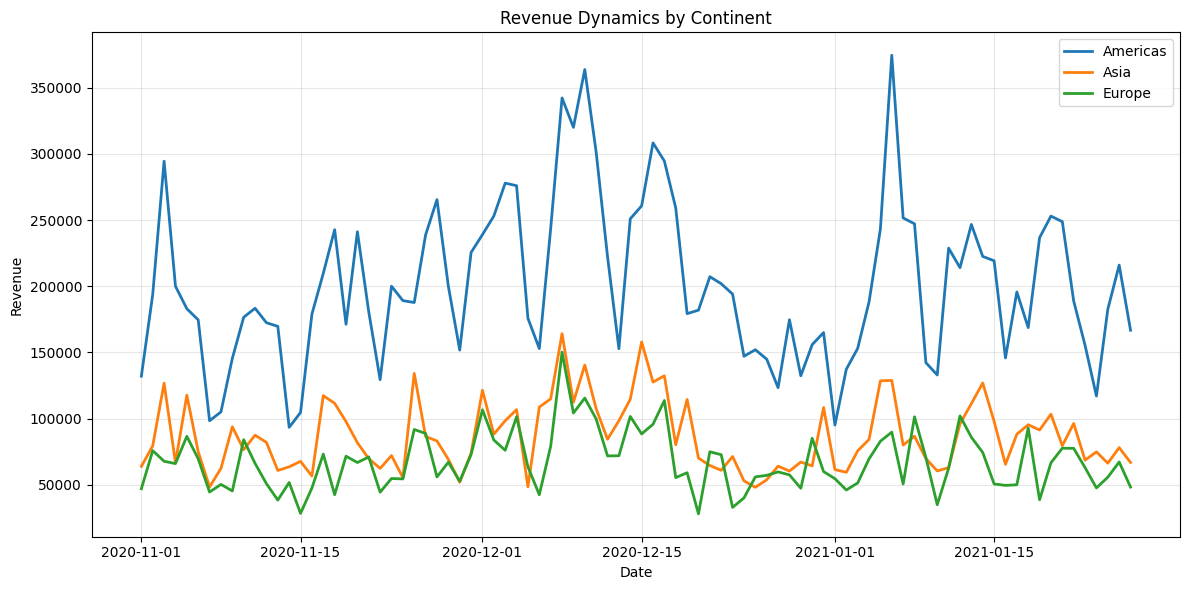

In [60]:
continent_trend = (
    orders_df.groupby(['session_date', 'continent'])['revenue']
    .sum()
    .unstack(fill_value=0)
)

top3_continents = (
    orders_df.groupby('continent')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)

continent_trend = continent_trend[top3_continents]

plt.figure(figsize=(12,6))
for col in continent_trend.columns:
    plt.plot(continent_trend.index, continent_trend[col], label=col, linewidth=2)

plt.title('Revenue Dynamics by Continent')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Аналіз динаміки продажів за континентами.**

---

Протягом усього досліджуваного періоду регіон Americas стабільно генерує найбільший дохід і суттєво випереджає Asia та Europe. Динаміка продажів у всіх трьох регіонах має хвилеподібний характер, однак коливання в Americas є значно більш вираженими. Це підтверджує, що саме Americas є ключовим джерелом доходу компанії.

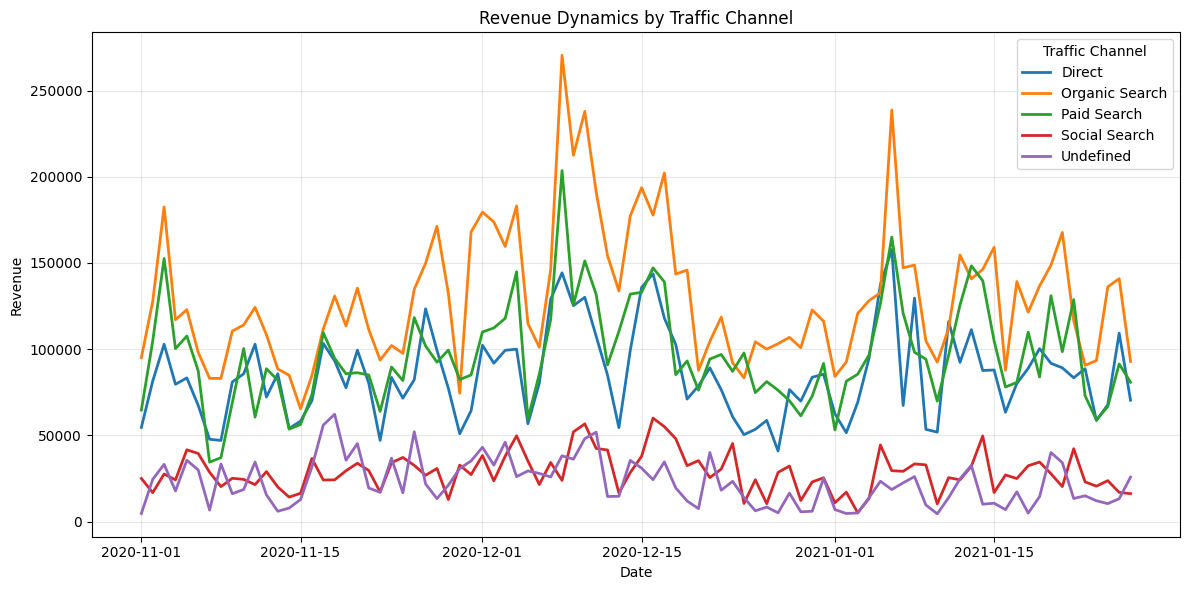

In [61]:
traffic_trend = (
    orders_df.groupby(['session_date', 'traffic_channel'])['revenue']
    .sum()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12,6))
for col in traffic_trend.columns:
    plt.plot(traffic_trend.index, traffic_trend[col], label=col, linewidth=2)

plt.title('Revenue Dynamics by Traffic Channel')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend(title='Traffic Channel')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Аналіз динаміки продажів за каналами трафіку.**

---

Найбільший внесок у дохід протягом усього періоду забезпечують Organic Search і Paid Search. Канал Direct також формує значну частку продажів, але поступається двом лідерам. Social Search та Undefined мають найменший внесок, а їхня динаміка залишається відносно низькою протягом усього періоду.

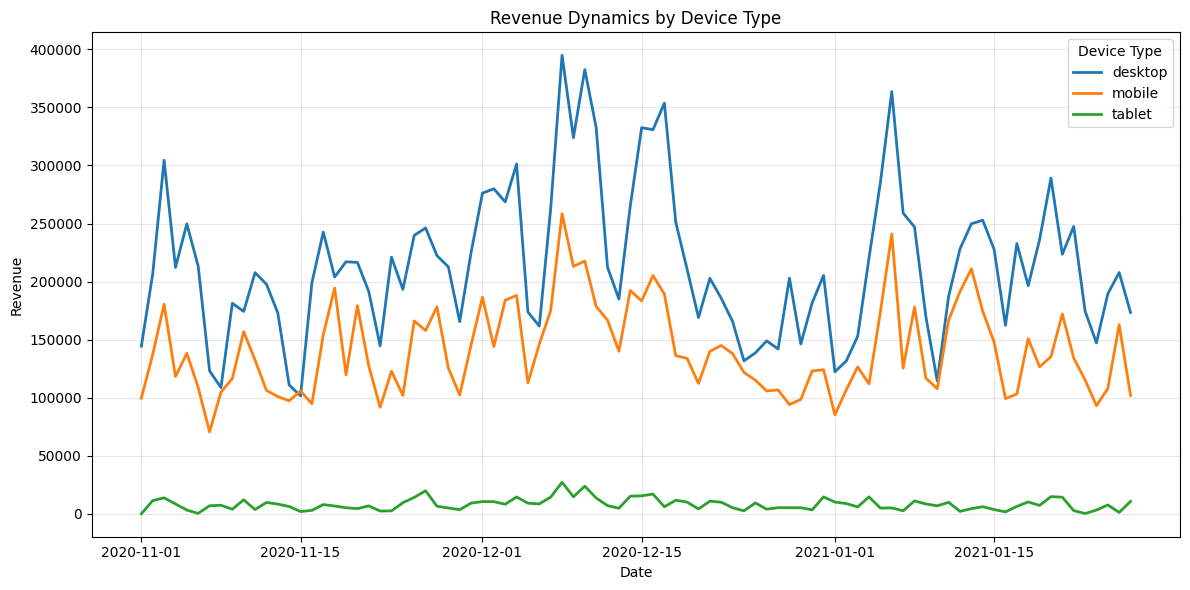

In [62]:
device_trend = (
    orders_df.groupby(['session_date', 'device'])['revenue']
    .sum()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12,6))
for col in device_trend.columns:
    plt.plot(device_trend.index, device_trend[col], label=col, linewidth=2)

plt.title('Revenue Dynamics by Device Type')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend(title='Device Type')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Аналіз динаміки продажів за типами девайсів.**

---

Протягом усього досліджуваного періоду найбільший дохід стабільно генерує desktop, який суттєво випереджає інші типи девайсів. Mobile також формує значну частку продажів, однак поступається desktop за більшістю дат. Tablet має найменший внесок у дохід, а його динаміка залишається низькою протягом усього періоду.

In [63]:
pivot_sessions = pd.pivot_table(
    df.dropna(subset=['traffic_channel', 'device']),
    index='traffic_channel',
    columns='device',
    values='ga_session_id',
    aggfunc='nunique',
    fill_value=0
)
pivot_sessions

device,desktop,mobile,tablet
traffic_channel,,,
Direct,47825,31745,1812
Organic Search,72622,49014,2789
Paid Search,55167,37034,2140
Social Search,16288,10988,638
Undefined,12527,8486,470


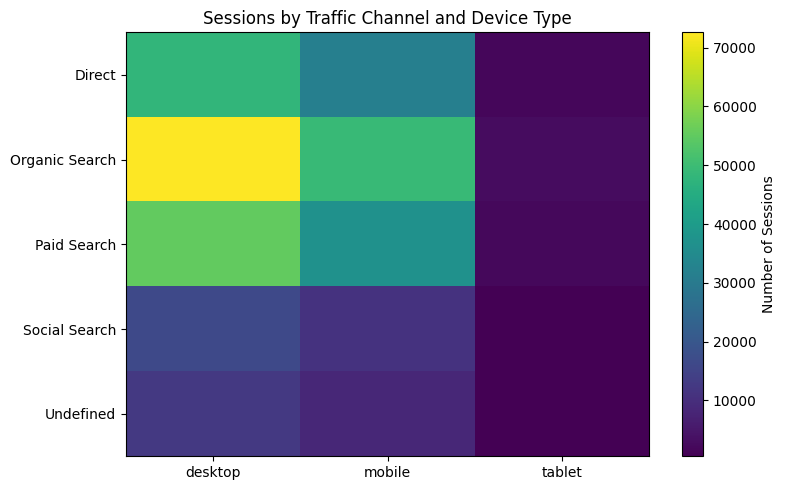

In [64]:
plt.figure(figsize=(8,5))
plt.imshow(pivot_sessions, aspect='auto')
plt.colorbar(label='Number of Sessions')
plt.title('Sessions by Traffic Channel and Device Type')
plt.xticks(range(len(pivot_sessions.columns)), pivot_sessions.columns)
plt.yticks(range(len(pivot_sessions.index)), pivot_sessions.index)
plt.tight_layout()
plt.show()

**Аналіз зведеної таблиці сесій.**

---

Найбільшу кількість сесій формують канали Organic Search, Paid Search та Direct. У всіх каналах домінують пристрої типу desktop та mobile, тоді як tablet має найменшу кількість сесій. Це свідчить про те, що основна аудиторія сайту взаємодіє з ним переважно через desktop і mobile.

In [65]:
top10_categories = (
    orders_df.groupby('category')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

top5_countries = (
    orders_df.groupby('country')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

pivot_sales = pd.pivot_table(
    orders_df[
        orders_df['category'].isin(top10_categories) &
        orders_df['country'].isin(top5_countries)
    ],
    index='category',
    columns='country',
    values='revenue',
    aggfunc='sum',
    fill_value=0
)

pivot_sales

country,Canada,France,India,United Kingdom,United States
category,,,,,
Bar furniture,51724.0,11199.0,57657.0,22103.0,330805.0
Beds,354772.0,116414.0,358319.5,133816.0,2213058.0
Bookcases & shelving units,278981.9,73830.0,364507.4,113987.6,1567606.9
Cabinets & cupboards,181802.0,59101.5,191888.0,71684.5,994545.5
Chairs,417740.8,134029.4,544309.2,188519.4,2619773.8
Chests of drawers & drawer units,71952.0,21544.5,73111.0,36784.0,382388.0
Children's furniture,30264.0,14258.0,39177.0,13348.0,207575.0
Outdoor furniture,185322.8,40486.4,162289.4,57002.4,929245.2
Sofas & armchairs,692427.5,187735.0,788430.0,234812.0,3707144.5


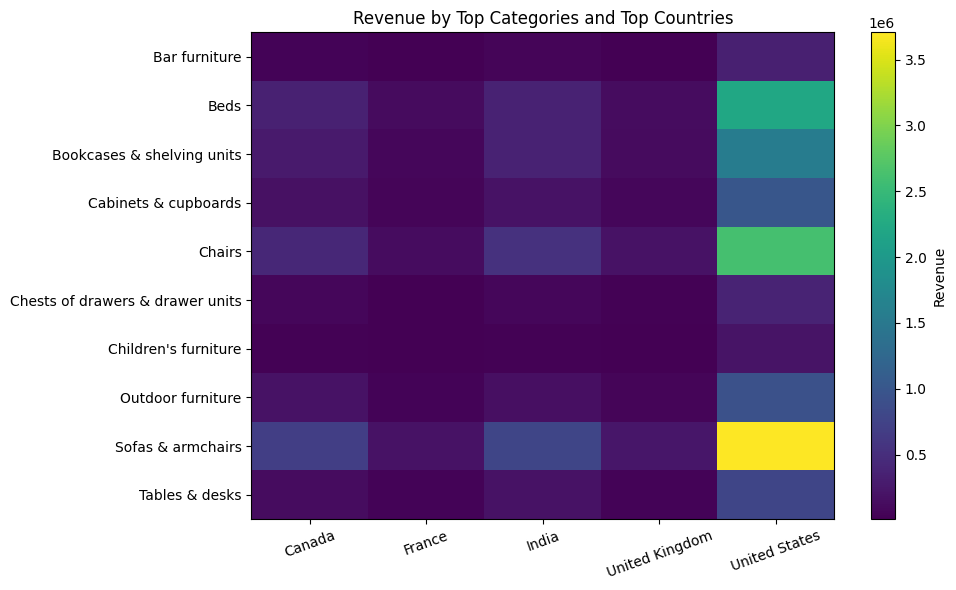

In [66]:
plt.figure(figsize=(10,6))
plt.imshow(pivot_sales, aspect='auto')
plt.colorbar(label='Revenue')
plt.title('Revenue by Top Categories and Top Countries')
plt.xticks(range(len(pivot_sales.columns)), pivot_sales.columns, rotation=20)
plt.yticks(range(len(pivot_sales.index)), pivot_sales.index)
plt.tight_layout()
plt.show()

Найбільші продажі в більшості топових категорій припадають на United States, а категорії Sofas & armchairs, Chairs та Beds домінують у кількох країнах одночасно.

In [67]:
pivot_continent_channel = pd.pivot_table(
    orders_df,
    index='continent',
    columns='traffic_channel',
    values='revenue',
    aggfunc='sum',
    fill_value=0
)

pivot_continent_channel

traffic_channel,Direct,Organic Search,Paid Search,Social Search,Undefined
continent,,,,,
(not set),21443.0,15080.0,19931.0,11224.4,6389.0
Africa,70028.0,129908.4,88195.0,31187.6,11912.0
Americas,4222962.0,6294563.2,4627454.3,1384427.7,1135872.8
Asia,1755294.5,2725953.8,2039256.5,576031.8,504761.7
Europe,1343093.9,2154138.6,1620206.1,498507.1,318678.5
Oceania,82102.0,113507.6,116006.5,30727.1,22887.0


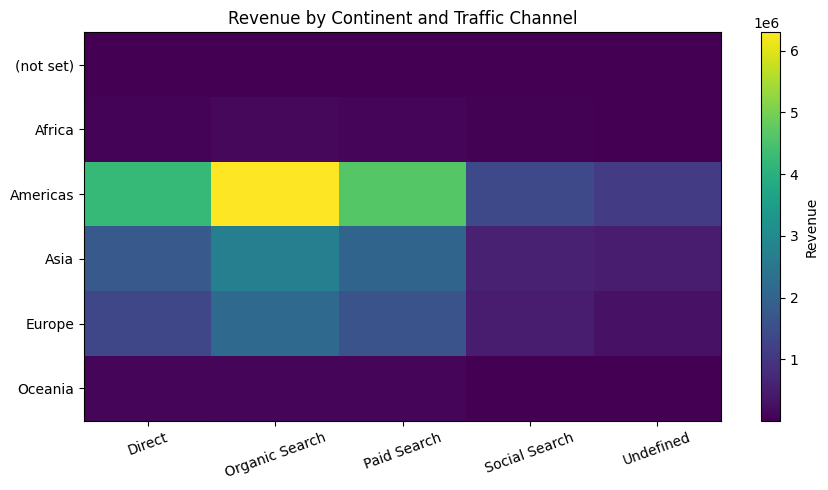

In [68]:
plt.figure(figsize=(9,5))
plt.imshow(pivot_continent_channel, aspect='auto')
plt.colorbar(label='Revenue')
plt.title('Revenue by Continent and Traffic Channel')
plt.xticks(range(len(pivot_continent_channel.columns)), pivot_continent_channel.columns, rotation=20)
plt.yticks(range(len(pivot_continent_channel.index)), pivot_continent_channel.index)
plt.tight_layout()
plt.show()

Основний дохід у більшості каналів формується в регіоні Americas.

In [69]:
top_browsers = (
    orders_df.groupby('browser')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

pivot_browser_device = pd.pivot_table(
    orders_df[orders_df['browser'].isin(top_browsers)],
    index='browser',
    columns='device',
    values='revenue',
    aggfunc='sum',
    fill_value=0
)

pivot_browser_device

device,desktop,mobile,tablet
browser,,,
<Other>,318000.9,544545.3,60808.6
Chrome,15778375.2,5667208.9,381265.9
Edge,716444.3,0.0,0.0
Firefox,535659.6,31864.0,0.0
Safari,1515559.0,5748221.2,262763.8


Найбільший дохід генерується комбінаціями браузерів і пристроїв, пов’язаними з desktop-сесіями

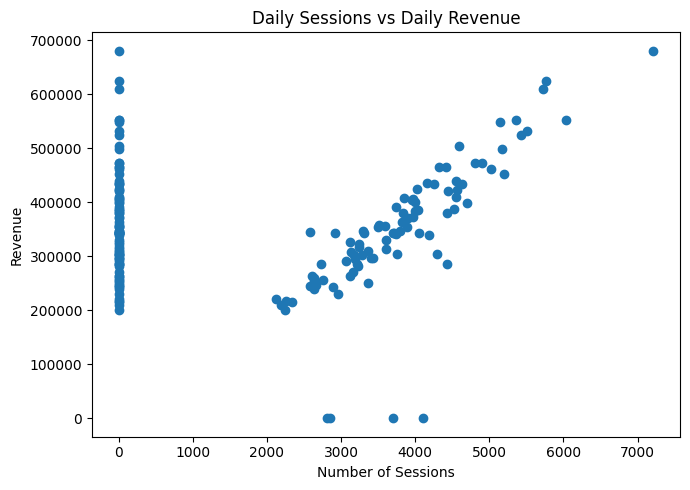

Pearson correlation: 0.1423 p-value: 0.05667581128188389
Spearman correlation: 0.211 p-value: 0.00447296337543656


In [70]:
daily_sessions = df.groupby('session_date')['ga_session_id'].nunique()
daily_revenue = orders_df.groupby('session_date')['revenue'].sum()

daily_corr_df = pd.concat([daily_sessions, daily_revenue], axis=1).fillna(0)
daily_corr_df.columns = ['sessions', 'revenue']

plt.figure(figsize=(7,5))
plt.scatter(daily_corr_df['sessions'], daily_corr_df['revenue'])
plt.title('Daily Sessions vs Daily Revenue')
plt.xlabel('Number of Sessions')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

pearson_corr, pearson_p = pearsonr(daily_corr_df['sessions'], daily_corr_df['revenue'])
spearman_corr, spearman_p = spearmanr(daily_corr_df['sessions'], daily_corr_df['revenue'])

print("Pearson correlation:", round(pearson_corr, 4), "p-value:", pearson_p)
print("Spearman correlation:", round(spearman_corr, 4), "p-value:", spearman_p)

**Статистичний аналіз взаємозв’язку між кількістю сесій та доходом.**

---

Для перевірки зв’язку між щоденною кількістю сесій та доходом було розраховано коефіцієнти Pearson і Spearman. Якщо p-value < 0.05, зв’язок є статистично значущим. Для інтерпретації в підсумку краще спиратися на Spearman, якщо дані мають нерівномірний розподіл.

In [71]:
continent_daily = (
    orders_df.groupby(['session_date', 'continent'])['revenue']
    .sum()
    .unstack(fill_value=0)
)

top3_continents = (
    orders_df.groupby('continent')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)

continent_daily = continent_daily[top3_continents]

continent_corr = continent_daily.corr(method='spearman')
print(continent_corr)

for i in range(len(top3_continents)):
    for j in range(i+1, len(top3_continents)):
        c1 = top3_continents[i]
        c2 = top3_continents[j]
        corr, p = spearmanr(continent_daily[c1], continent_daily[c2])
        print(f"{c1} vs {c2}: Spearman={corr:.4f}, p-value={p}")

continent  Americas      Asia    Europe
continent                              
Americas   1.000000  0.668539  0.625885
Asia       0.668539  1.000000  0.608221
Europe     0.625885  0.608221  1.000000
Americas vs Asia: Spearman=0.6685, p-value=1.1001059722381636e-12
Americas vs Europe: Spearman=0.6259, p-value=7.009052955139405e-11
Asia vs Europe: Spearman=0.6082, p-value=3.2731384105062476e-10


**Статистичний аналіз взаємозв’язку між продажами на різних континентах.**

---

Для оцінки взаємозв’язку між щоденними продажами на топ-3 континентах було використано коефіцієнт кореляції Spearman. Отримані результати показали, що між усіма парами континентів спостерігається помірний додатний зв’язок:

між **Americas** та **Asia**: **Spearman = 0.6685**

між **Americas** та **Europe**: **Spearman = 0.6259**

між **Asia** та **Europ**e: **Spearman = 0.6082**

У всіх трьох випадках** p-value є значно меншим за 0.05**, отже виявлені зв’язки є **статистично значущими**. Це означає, що динаміка продажів на цих континентах змінюється узгоджено: коли продажі зростають в одному регіоні, вони, як правило, зростають і в інших.

Найсильніший зв’язок спостерігається між **Americas** та **Asia**, що може свідчити про найбільш подібну поведінку продажів у цих двох регіонах. Зв’язки між **Americas** та **Europe**, а також між **Asia** та **Europe** також є помірними та статистично значущими. Таким чином, можна зробити висновок, що між продажами на основних континентах існує спільна тенденція змін у часі.

In [72]:
traffic_daily = (
    orders_df.groupby(['session_date', 'traffic_channel'])['revenue']
    .sum()
    .unstack(fill_value=0)
)

traffic_corr = traffic_daily.corr(method='spearman')
print(traffic_corr)

channels = traffic_daily.columns.tolist()
for i in range(len(channels)):
    for j in range(i+1, len(channels)):
        ch1 = channels[i]
        ch2 = channels[j]
        corr, p = spearmanr(traffic_daily[ch1], traffic_daily[ch2])
        print(f"{ch1} vs {ch2}: Spearman={corr:.4f}, p-value={p}")

traffic_channel    Direct  Organic Search  Paid Search  Social Search  \
traffic_channel                                                         
Direct           1.000000        0.748248     0.690782       0.393681   
Organic Search   0.748248        1.000000     0.763922       0.384770   
Paid Search      0.690782        0.763922     1.000000       0.420397   
Social Search    0.393681        0.384770     0.420397       1.000000   
Undefined        0.493748        0.456905     0.493255       0.385897   

traffic_channel  Undefined  
traffic_channel             
Direct            0.493748  
Organic Search    0.456905  
Paid Search       0.493255  
Social Search     0.385897  
Undefined         1.000000  
Direct vs Organic Search: Spearman=0.7482, p-value=5.362547239818307e-17
Direct vs Paid Search: Spearman=0.6908, p-value=9.505458925584083e-14
Direct vs Social Search: Spearman=0.3937, p-value=0.00014782706768003086
Direct vs Undefined: Spearman=0.4937, p-value=1.0172911287944853e-06


**Висновок.**

---

Між усіма каналами трафіку виявлено додатну статистично значущу кореляцію. Найсильніший зв’язок спостерігається між Organic Search і Paid Search (0.7639), а також між Direct і Organic Search (0.7482). Це свідчить про те, що динаміка продажів у ключових каналах трафіку змінюється узгоджено, тоді як Social Search та Undefined мають слабший, але значущий зв’язок з іншими каналами.

In [73]:
top5_categories = (
    orders_df.groupby('category')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

category_daily = (
    orders_df[orders_df['category'].isin(top5_categories)]
    .groupby(['session_date', 'category'])['revenue']
    .sum()
    .unstack(fill_value=0)
)

category_corr = category_daily.corr(method='spearman')
print(category_corr)

cats = category_daily.columns.tolist()
for i in range(len(cats)):
    for j in range(i+1, len(cats)):
        cat1 = cats[i]
        cat2 = cats[j]
        corr, p = spearmanr(category_daily[cat1], category_daily[cat2])
        print(f"{cat1} vs {cat2}: Spearman={corr:.4f}, p-value={p}")

category                        Beds  Bookcases & shelving units  \
category                                                           
Beds                        1.000000                    0.542742   
Bookcases & shelving units  0.542742                    1.000000   
Cabinets & cupboards        0.440368                    0.528706   
Chairs                      0.534941                    0.636751   
Sofas & armchairs           0.521715                    0.625603   

category                    Cabinets & cupboards    Chairs  Sofas & armchairs  
category                                                                       
Beds                                    0.440368  0.534941           0.521715  
Bookcases & shelving units              0.528706  0.636751           0.625603  
Cabinets & cupboards                    1.000000  0.526822           0.631204  
Chairs                                  0.526822  1.000000           0.583319  
Sofas & armchairs                       0.6

Між продажами топ-5 категорій товарів виявлено помірний додатний статистично значущий зв’язок. Найсильніша кореляція спостерігається між Bookcases & shelving units і Chairs (0.6368), а також між Cabinets & cupboards і Sofas & armchairs (0.6312). Усі p-value є меншими за 0.05, тому можна стверджувати, що динаміка продажів провідних категорій пов’язана між собою

              registered  non_registered
session_date                            
2020-11-01       21547.0        222745.5
2020-11-02       44956.8        310550.0
2020-11-03       29150.5        469829.1
2020-11-04       20982.2        318204.9
2020-11-05       25334.6        365942.0


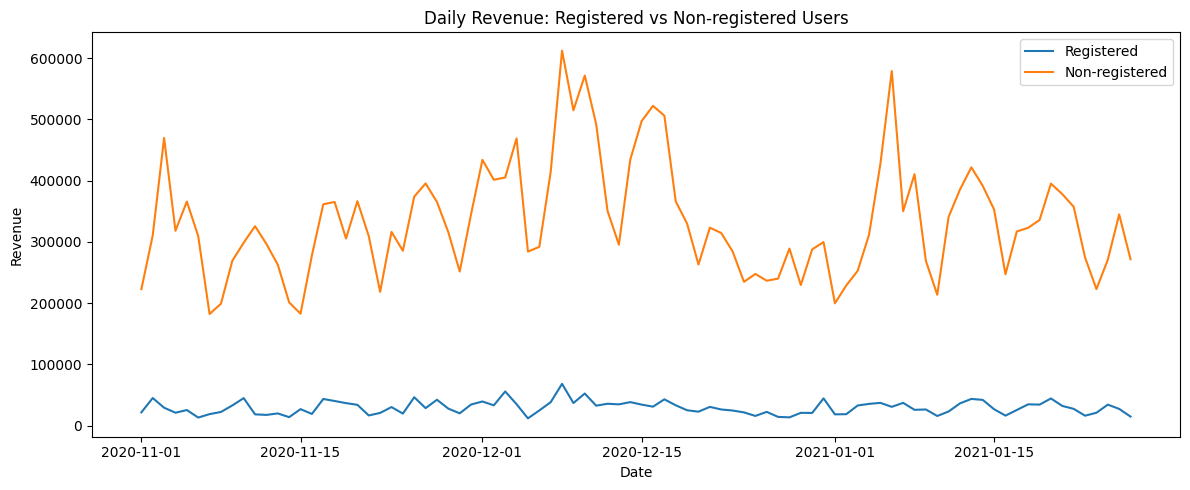

Shapiro registered: ShapiroResult(statistic=np.float64(0.9591810175035426), pvalue=np.float64(0.007295139880540744))
Shapiro non-registered: ShapiroResult(statistic=np.float64(0.9521579282190968), pvalue=np.float64(0.0026183359245325936))
Mann-Whitney U: 0.0 p-value: 2.2159276950123465e-30


In [74]:
daily_reg = (
    orders_df[orders_df['user_id'].notna()]
    .groupby('session_date')['revenue']
    .sum()
)

daily_nonreg = (
    orders_df[orders_df['user_id'].isna()]
    .groupby('session_date')['revenue']
    .sum()
)

compare_reg_df = pd.concat([daily_reg, daily_nonreg], axis=1).fillna(0)
compare_reg_df.columns = ['registered', 'non_registered']

print(compare_reg_df.head())

plt.figure(figsize=(12,5))
plt.plot(compare_reg_df.index, compare_reg_df['registered'], label='Registered')
plt.plot(compare_reg_df.index, compare_reg_df['non_registered'], label='Non-registered')
plt.title('Daily Revenue: Registered vs Non-registered Users')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.tight_layout()
plt.show()

shapiro_reg = shapiro(compare_reg_df['registered'])
shapiro_nonreg = shapiro(compare_reg_df['non_registered'])

print("Shapiro registered:", shapiro_reg)
print("Shapiro non-registered:", shapiro_nonreg)

u_stat, u_p = mannwhitneyu(compare_reg_df['registered'], compare_reg_df['non_registered'], alternative='two-sided')
print("Mann-Whitney U:", u_stat, "p-value:", u_p)

**Статистичний аналіз відмінностей між зареєстрованими та незареєстрованими користувачами.**

---

Для порівняння щоденного доходу було сформовано дві вибірки: доходи від зареєстрованих та незареєстрованих користувачів. Після перевірки розподілу даних застосовано тест Mann–Whitney U. Якщо p-value < 0.05, відмінності між групами є статистично значущими.

In [75]:
daily_channel_sessions = (
    df.groupby(['session_date', 'traffic_channel'])['ga_session_id']
    .nunique()
    .unstack(fill_value=0)
)

groups = [daily_channel_sessions[col] for col in daily_channel_sessions.columns]

kw_stat, kw_p = kruskal(*groups)

print("Kruskal-Wallis statistic:", kw_stat)
print("p-value:", kw_p)

Kruskal-Wallis statistic: 368.98057369864847
p-value: 1.397036102599359e-78


**Статистичний аналіз кількості сесій за каналами трафіку.**

---

Оскільки порівнюються більше ніж дві групи, а розподіли можуть бути ненормальними, для перевірки використано Kruskal–Wallis test. Якщо p-value < 0.05, між каналами трафіку існують статистично значущі відмінності за кількістю сесій.

In [76]:
session_level = df[['ga_session_id', 'continent', 'traffic_channel']].drop_duplicates()

eu_total = session_level[session_level['continent'] == 'Europe']['ga_session_id'].nunique()
am_total = session_level[session_level['continent'] == 'Americas']['ga_session_id'].nunique()

eu_organic = session_level[
    (session_level['continent'] == 'Europe') &
    (session_level['traffic_channel'] == 'Organic Search')
]['ga_session_id'].nunique()

am_organic = session_level[
    (session_level['continent'] == 'Americas') &
    (session_level['traffic_channel'] == 'Organic Search')
]['ga_session_id'].nunique()

count = np.array([eu_organic, am_organic])
nobs = np.array([eu_total, am_total])

z_stat, z_p = proportions_ztest(count, nobs)

print("Europe organic sessions:", eu_organic, "out of", eu_total)
print("Americas organic sessions:", am_organic, "out of", am_total)
print("Z-statistic:", z_stat)
print("p-value:", z_p)

Europe organic sessions: 23195 out of 65135
Americas organic sessions: 68671 out of 193179
Z-statistic: 0.28951412926103953
p-value: 0.7721879690501752


**Порівняння частки органічного трафіку в Європі та Америці.**

---

Для порівняння двох часток використано z-test for proportions. Якщо p-value < 0.05, можна зробити висновок, що частка сесій з органічним трафіком у Європі та Америці статистично відрізняється.

In [77]:
device_daily = (
    orders_df[orders_df['device'].isin(['desktop', 'mobile'])]
    .groupby(['session_date', 'device'])['revenue']
    .sum()
    .unstack(fill_value=0)
)

u_stat_device, u_p_device = mannwhitneyu(
    device_daily['desktop'],
    device_daily['mobile'],
    alternative='two-sided'
)

print("Desktop vs Mobile Mann-Whitney U:", u_stat_device)
print("p-value:", u_p_device)

Desktop vs Mobile Mann-Whitney U: 6554.0
p-value: 2.119819953178567e-15


Для порівняння щоденного доходу desktop і mobile було використано тест Mann–Whitney

In [78]:
contingency = pd.crosstab(df['traffic_channel'], df['device'])

chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 4.73916506994021
p-value: 0.7850559692480474
Degrees of freedom: 8


Для перевірки залежності між типом девайса та каналом трафіку було використано критерій хі-квадрат

**Загальний підсумок проєкту**

У межах цього аналітичного проекту було сформовано датасет на основі SQL-запиту в BigQuery, виконано підготовку та обробку даних у Python, а також проведено аналіз ключових показників продажів інтернет-магазину.

У результаті аналізу встановлено, що найбільший дохід компанія отримує в регіоні Americas, зокрема у United States. Серед товарних категорій найбільший внесок у дохід забезпечують Sofas & armchairs, Chairs та Beds, що свідчить про високий попит на базові меблі для дому. Також було виявлено, що основна частка продажів формується через desktop-пристрої та канали Organic Search і Paid Search.

Отримані результати можуть бути використані для визначення пріоритетних ринків, оптимізації маркетингових каналів і фокусування на найбільш прибуткових товарних категоріях. Таким чином, проект демонструє практичне застосування SQL, Python і засобів візуалізації для бізнес-аналітики та прийняття рішень на основі даних.

In [79]:
df.to_csv("sales_dataset.csv", index=False)

from google.colab import files
files.download("sales_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Tableau Dashboard

Tableau Public:
https://public.tableau.com/app/profile/miroszlava.balog/viz/GotoCustomerChannelInsights_/Dashboard1